<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>

# Data Science for Businnes

## Prof. Eduardo Pécora

## Ridge, Lasso, ElasticNet Regressions
Tempo estimado: **60** minutos

## Objetivos

Após completar esta aula, você será capaz de:

* Comparar as regressões
* Estimar os hiper-parâmetros usando GridSearch

## Bibliotecas

In [49]:
# importando a biblioteca pandas para manipulação de dados
import pandas as pd

# Iportando numpy para criar, manipular e operar em arrays multidimensionais, bem como para realizar operações matemáticas avançadas.
import numpy as np

# Importando a biblioteca math que fornece funções matemáticas básicas
import math

# importando as bibliotecas do matplotlib para gerar gráficos
import matplotlib as mpl
import matplotlib.pyplot as plt

# Importando biblioteca do seaborn para gerar gráficos mais atraentes e informativos
import seaborn as sns

# Importando a classe LinearRegression do sklearn
# Essa classe implementa uma versão da regressão linear simples ou múltipla
# Usado para modelar a relação entre uma variável dependente contínua e uma ou mais variáveis independentes.
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Usado para exibir os gráficos gerados pela biblioteca Matplotlib diretamente no notebook, sem precisar abrir uma janela externa.
%matplotlib inline

## Obtendo dados

In [50]:
# Caminho do arquivo csv
caminho = "https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Dados/MeuAutoLimpo.csv"

#Obtendo arquivo e passando-o para um dataframe
df = pd.read_csv(caminho)

#Obtendo colunas categóricas
cat = ['object']
df_cat = df.select_dtypes(include=cat)
df_cat

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system
0,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
196,volvo,gas,std,four,sedan,rwd,front,ohc,four,mpfi
197,volvo,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
198,volvo,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
199,volvo,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


In [51]:
#Corrigindo problemas na feature 'make'
df_cat['make'] = df_cat['make'].replace({'bmw': 'BMW','doge':'dodge','volkswagen':'VW','volvo':'volv1'})

# Crie uma instância do codificador OneHotEncoder
encoder = OneHotEncoder()

# Ajuste e transforme os dados da coluna "make"
dummy_array = encoder.fit_transform(df_cat)

# Crie um DataFrame Pandas com as variáveis dummy
dummy_df = pd.DataFrame(dummy_array.toarray(), columns=encoder.get_feature_names_out())

# Concatene o DataFrame dummy com os outros dados
df_cat = pd.concat([df.drop(df.select_dtypes(include=cat).columns, axis=1), dummy_df], axis=1)

df_cat.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_1bbl,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3,122,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3,122,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1,164,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2,164,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2,164,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Train Test Split

In [52]:
X = df_cat[df_cat.drop(labels='price',axis='columns').columns]
Y = df_cat['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

print("Shape train = ",X_train.shape)
print("Shape test = ",X_test.shape)

Shape train =  (150, 74)
Shape test =  (51, 74)


## Baseline: Linear Regression

In [81]:
param_grid_linear = {
    "fit_intercept": [True, False]
}

grid_linear = GridSearchCV(
    LinearRegression(),
    param_grid=param_grid_linear,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_linear.fit(X_train, y_train)

print("Melhores parâmetros - Linear Regression:")
print(grid_linear.best_params_)
print("Melhor score CV:", grid_linear.best_score_)

Melhores parâmetros - Linear Regression:
{'fit_intercept': False}
Melhor score CV: 0.8394470464093458


LinearRegression(fit_intercept=False)

## Ridge Regression

In [54]:
param_grid_ridge = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100],
    "fit_intercept": [True, False]
}

grid_ridge = GridSearchCV(
    Ridge(max_iter=10000),
    param_grid=param_grid_ridge,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)

print("Melhores parâmetros - Ridge:")
print(grid_ridge.best_params_)
print("Melhor score CV:", grid_ridge.best_score_)

Melhores parâmetros - Ridge:
{'alpha': 1, 'fit_intercept': True}
Melhor score CV: 0.8608690526974989


## Lasso Regression

In [55]:
param_grid_lasso = {
    "alpha": [0.001, 0.01, 0.1, 1, 10],
    "fit_intercept": [True, False]
}

grid_lasso = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid=param_grid_lasso,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_lasso.fit(X_train, y_train)

print("Melhores parâmetros - Lasso:")
print(grid_lasso.best_params_)
print("Melhor score CV:", grid_lasso.best_score_)

Melhores parâmetros - Lasso:
{'alpha': 10, 'fit_intercept': False}
Melhor score CV: 0.8566727102055085


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.121e+08, tolerance: 3.069e+06
  model = cd_fast.enet_coordinate_descent(


## Elastic Net

In [56]:
param_grid_elastic = {
    "alpha": [0.001, 0.01, 0.1, 1, 10],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    "fit_intercept": [True, False]
}

grid_elastic = GridSearchCV(
    ElasticNet(max_iter=10000),
    param_grid=param_grid_elastic,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_elastic.fit(X_train, y_train)

print("Melhores parâmetros - Elastic Net:")
print(grid_elastic.best_params_)
print("Melhor score CV:", grid_elastic.best_score_)

Melhores parâmetros - Elastic Net:
{'alpha': 0.01, 'fit_intercept': True, 'l1_ratio': 0.5}
Melhor score CV: 0.8634373120726071


## Comparando os modelos

In [57]:
best_linear = grid_linear.best_estimator_
best_ridge = grid_ridge.best_estimator_
best_lasso = grid_lasso.best_estimator_
best_elastic = grid_elastic.best_estimator_

models = {
    "Linear Regression": best_linear,
    "Ridge": best_ridge,
    "Lasso": best_lasso,
    "Elastic Net": best_elastic
}

results = []

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results.append({
        "Modelo": name,
        "Train R2": r2_score(y_train, y_train_pred),
        "Test R2": r2_score(y_test, y_test_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred))
    })

results_df = pd.DataFrame(results)
results_df

,Modelo,Train R2,Test R2,Test RMSE
0,Linear Regression,0.970625,0.909144,3131.223968
1,Ridge,0.957349,0.930272,2743.096945
2,Lasso,0.964365,0.916315,3005.114592
3,Elastic Net,0.960442,0.933137,2686.153405


## Gráfico

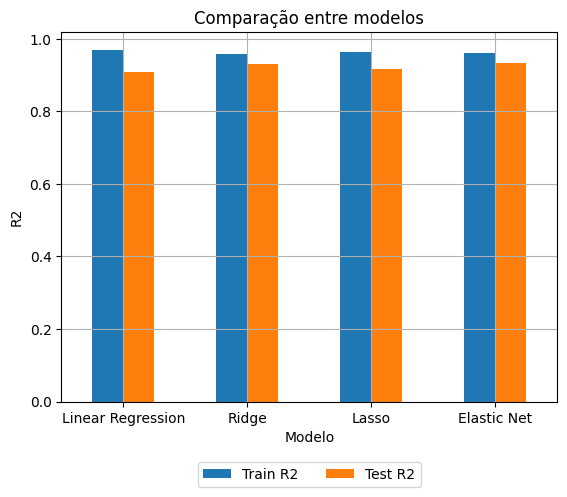

In [79]:
results_df.set_index("Modelo")[["Train R2", "Test R2"]].plot(kind="bar")
plt.title("Comparação entre modelos")
plt.ylabel("R2")
plt.xticks(rotation=0)
plt.grid()
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=6)
plt.show()

## Melhores parâmetros de cada modelo

In [91]:
print("Linear Regression:", grid_linear.best_params_)
print("Ridge:", grid_ridge.best_params_)
print("Lasso:", grid_lasso.best_params_)
print("Elastic Net:", grid_elastic.best_params_)

Linear Regression: {'fit_intercept': False}
Ridge: {'alpha': 1, 'fit_intercept': True}
Lasso: {'alpha': 10, 'fit_intercept': False}
Elastic Net: {'alpha': 0.01, 'fit_intercept': True, 'l1_ratio': 0.5}


## Comparando os coeficientes

In [92]:
coef_df = pd.DataFrame({
    "Variável": X.columns,
    "Linear": best_linear.coef_,
    "Ridge": best_ridge.coef_,
    "Lasso": best_lasso.coef_,
    "Elastic Net": best_elastic.coef_
})

coef_df.head(15)

,Variável,Linear,Ridge,Lasso,Elastic Net
0,symboling,-201.852379,85.550714,-21.454708,40.344620
1,normalized-losses,-1.750761,2.451081,-1.404270,2.268597
2,wheel-base,152.762983,204.636184,146.267743,205.112642
3,length,-119.554577,-83.142794,-80.241610,-90.594150
4,width,462.617816,415.577191,308.883621,426.733834
5,height,-224.368810,-77.331639,-187.249828,-104.216645
6,curb-weight,7.757682,3.970388,6.151065,4.474947
7,engine-size,4.956779,79.914309,36.303336,75.542038
8,bore,-1571.939152,-1995.891040,-2261.277838,-2199.006819
9,stroke,-517.890943,-1675.856476,-1007.764819,-1579.022275


In [93]:
print("Coeficientes zerados no Linear:", np.sum(best_linear.coef_ == 0))
print("Coeficientes zerados no Ridge:", np.sum(best_ridge.coef_ == 0))
print("Coeficientes zerados no Lasso:", np.sum(best_lasso.coef_ == 0))
print("Coeficientes zerados no Elastic Net:", np.sum(best_elastic.coef_ == 0))

Coeficientes zerados no Linear: 0
Coeficientes zerados no Ridge: 0
Coeficientes zerados no Lasso: 29
Coeficientes zerados no Elastic Net: 0


In [94]:
for feature, coef in zip(X.columns, best_lasso.coef_):
    if coef == 0:
        print(f"{feature} → REMOVIDA")
    else:
        print(f"{feature} → Mantida (coef = {coef:.3f})")

symboling → Mantida (coef = -21.455)
normalized-losses → Mantida (coef = -1.404)
wheel-base → Mantida (coef = 146.268)
length → Mantida (coef = -80.242)
width → Mantida (coef = 308.884)
height → Mantida (coef = -187.250)
curb-weight → Mantida (coef = 6.151)
engine-size → Mantida (coef = 36.303)
bore → Mantida (coef = -2261.278)
stroke → Mantida (coef = -1007.765)
compression-ratio → Mantida (coef = 89.166)
horsepower → Mantida (coef = 26.402)
peak-rpm → Mantida (coef = 0.526)
city-mpg → Mantida (coef = -87.347)
highway-mpg → Mantida (coef = 96.533)
make_BMW → Mantida (coef = 5830.206)
make_VW → REMOVIDA
make_alfa-romero → Mantida (coef = 136.994)
make_audi → Mantida (coef = 1185.563)
make_chevrolet → REMOVIDA
make_dodge → Mantida (coef = -1518.523)
make_honda → REMOVIDA
make_isuzu → Mantida (coef = -1364.240)
make_jaguar → Mantida (coef = 2195.750)
make_mazda → Mantida (coef = 535.416)
make_mercedes-benz → Mantida (coef = 252.194)
make_mercury → Mantida (coef = -167.366)
make_mitsubish

## Fique Conectado

- [![YouTube](https://img.icons8.com/?size=40&id=19318&format=png&color=000000)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/?size=40&id=13930&format=png&color=000000)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/?size=40&id=32323&format=png&color=000000)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!

## Referências:

* Documentação da biblioteca <a href="https://pandas.pydata.org/docs/">Pandas</a>
* Documentação do método <a href=https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html>train_test_split</a>
* Documentação do método <a href=https://scikit-learn.org/dev/modules/generated/sklearn.linear_model.Ridge.html>Ridge</a>
* Documentação do método <a href=https://scikit-learn.org/dev/modules/generated/sklearn.linear_model.Lasso.html>Lasso</a>
* Documentação do método <a href=https://scikit-learn.org/dev/modules/generated/sklearn.linear_model.ElasticNetCV.html>Elastic Net</a>



## Autores

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>


## Log de modificações

| Data | Versão | Modificado por | Descrição |
| -----------| ------- | ---------- | ---------------------------------- |
| 06-04-2026       | 1.0   | Eduardo Pecora    | Estrutura Aula        |


## <h3 align="center"> (c) Liga Data Science / UFPR 2026. All rights reserved. <h3/>
